# Exercise 4 — Dimensionality Reduction

## Part A — Why Do We Need Dimensionality Reduction?

Real datasets often contain many features.

Example:
```
apartment:
- size
- number of rooms
- floor
- location score
- age
- distance to center
- noise level
- energy consumption
...
```

As the number of features increases:

* visualization becomes difficult
* models become slower
* features may become redundant
* noise increases
* overfitting becomes easier

This is related to: `the curse of dimensionality`

### Goal of Dimensionality Reduction

Reduce the number of features while preserving the important structure of the data.

### Main Idea

Instead of describing the data with many correlated features: `(size, rooms, floor, age, ...)` we create: `new compact features` called `principal components`.

If two features contain similar information: `size ↔ number of rooms` then we may not need both.

PCA tries to find:

* the main directions of variation
* the most informative axes

## Part B — Generate Correlated Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Apartment example
n = 120

size = np.random.normal(70, 15, n)

rooms = size / 25 + np.random.normal(0, 0.35, n)

X = np.column_stack([size, rooms])

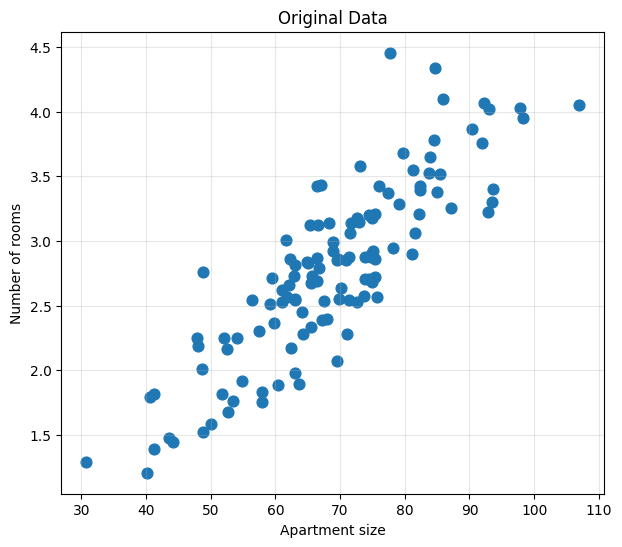

In [2]:
plt.figure(figsize=(7,6))

plt.scatter(X[:,0], X[:,1], s=60)

plt.xlabel("Apartment size")
plt.ylabel("Number of rooms")

plt.title("Original Data")

plt.grid(True, alpha=0.3)

plt.show()

### Questions

1. Are the features correlated?
2. Does the cloud follow a direction?
3. Could one feature approximately predict the other?

## Part C — Apply PCA

Standardize the data. Why do we need to do this?

Data standardization is the process of scaling variables so they have a mean of 0 and a standard deviation 1. It is a mandatory first step in PCA to prevent features with larger units or magnitudes from disproportionately dominating the analysis.

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Run PCA

In [16]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Explained Variance

In [17]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

Explained variance ratio:
[0.92920937 0.07079063]


`PC1 = direction with maximum variance`

PCA tries to find the direction where the data spreads the most.

### Visualize PCA Directions

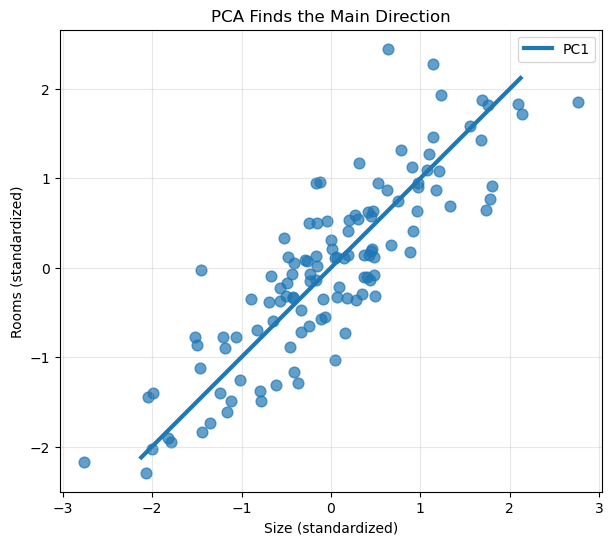

In [18]:
mean = X_scaled.mean(axis=0)

pc1 = pca.components_[0]

t = np.linspace(-3, 3, 100)

pc1_line = mean + t[:, None] * pc1

plt.figure(figsize=(7,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60,
    alpha=0.7
)

plt.plot(
    pc1_line[:,0],
    pc1_line[:,1],
    linewidth=3,
    label="PC1"
)

plt.xlabel("Size (standardized)")
plt.ylabel("Rooms (standardized)")

plt.title("PCA Finds the Main Direction")

plt.legend()

plt.grid(True, alpha=0.3)

plt.axis("equal")

plt.show()

### Questions

1. Why does PCA choose this direction?
2. What does “maximum variance” mean visually?
3. Why is this direction informative?

## Part D — Reduce to One Dimension

In [19]:
pca_1d = PCA(n_components=1)

X_reduced = pca_1d.fit_transform(X_scaled)

print(X_reduced.shape)

(120, 1)


### Before vs After PCA

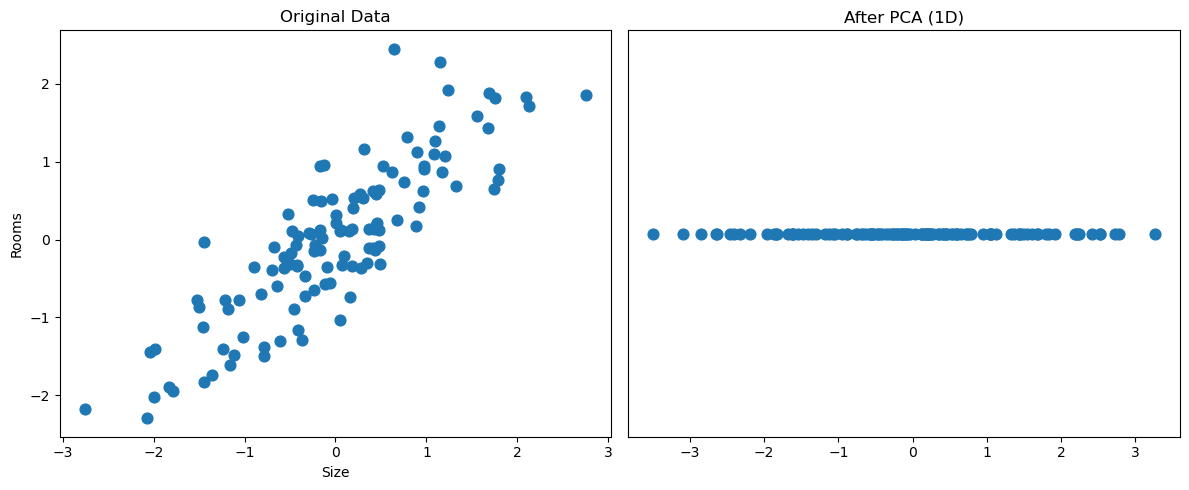

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Original
axes[0].scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60
)

axes[0].set_title("Original Data")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Rooms")

# Reduced
axes[1].scatter(
    X_reduced[:,0],
    np.zeros_like(X_reduced[:,0]),
    s=60
)

axes[1].set_title("After PCA (1D)")
axes[1].set_yticks([])

plt.tight_layout()

plt.show()

Even after reducing dimensions: `similar apartments stay close together`

PCA compresses the data while preserving important relationships.

## Part E — Real Dataset

Now apply PCA to a real dataset.

Choose one dataset from the table below.

| Dataset | Link | Features | What PCA can help with |
|---|---|---|---|
| Iris | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) | flower measurements | visualize species in 2D |
| Wine | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) | chemical properties | reduce many chemical features |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | tumor measurements | visualize benign vs malignant cases |
| Digits | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) | image pixels | compress image features |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | biological measurements | visualize species groups |
| Wine Quality | [Open dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) | chemical properties | reduce correlated wine features |

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

### Apply PCA to 2D

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Visualize Reduced Data

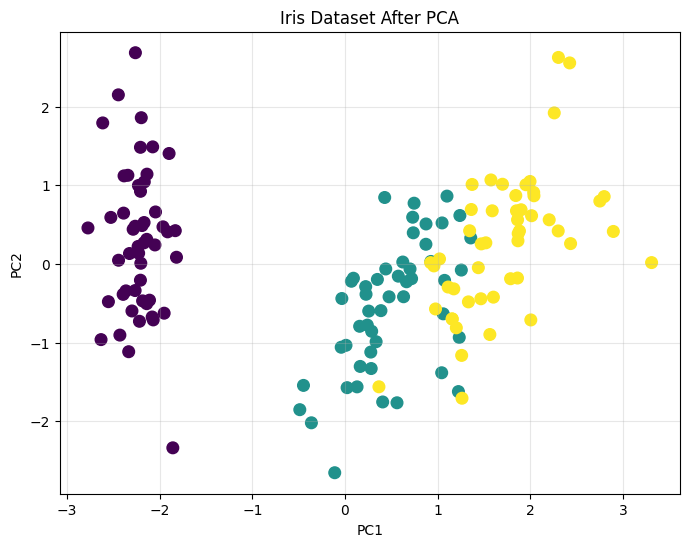

In [11]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    s=70
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Iris Dataset After PCA")

plt.grid(True, alpha=0.3)

plt.show()

### Questions

1. Do the classes separate well?
2. Which species overlap?
3. Why is PCA useful for visualization?
4. Why can PCA help machine learning models?

## Part F — Train a Model with Logistic Regression and PCA


Look in the previous exercises and find how to load a dataset, separate it in train/dev/test or just train/dev datasets. 

1. Use [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) or [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) depending on the task to train and test a model. Please report accuracy, precision and recall.
2. Use then PCA to reduce the dimensionality of the data, and redo step 1. Report metrics and see the difference. Is there any?

# Part B
1. Yes (bigger apartment usually means more rooms)
2. Yes (line with positive slope)
3. Yes

# Part C
1. Because it's the direction with maximum variance
2. It's the direction in which the data spreads out the most, looks like a linear line fitting the data points
3. The slope and shift of the line represent the correlation between the attributes

# Part E
1. One of the classes seperate well, two others don't
2. Iris Versicolor & Iris Virginica (classes 1 and 2; plot colors green and yellow)
3. It groups similar data elements closely together on a graph
4. It reduces dimensionality, thus simplifies learning algorithms and computational power required